In [1]:
# ============================================================
# 0. IMPORTS & SETUP
# ============================================================
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
from copy import deepcopy

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
# ============================================================
# 1. DATA LOADING
# ============================================================
def load_casting_images(root):
    img_paths, labels = [], []
    for label, cls in enumerate(["ok_front", "def_front"]):
        cls_path = os.path.join(root, cls)
        if not os.path.exists(cls_path): continue
        for f in os.listdir(cls_path):
            img_paths.append(os.path.join(cls_path, f))
            labels.append(label)
    return img_paths, labels

train_root = "/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train"
test_root  = "/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test"

train_imgs, train_lbls = load_casting_images(train_root)
test_imgs, test_lbls = load_casting_images(test_root)

all_imgs = train_imgs + test_imgs
all_lbls = train_lbls + test_lbls

# %80 SSL (Etiketsiz) - %20 Sınıflandırma Split
ssl_imgs, cls_imgs, _, cls_lbls = train_test_split(
    all_imgs, all_lbls, test_size=0.20, stratify=all_lbls, random_state=42
)

# Sınıflandırma için Train/Test Ayırımı
cls_train_imgs, cls_test_imgs, cls_train_lbls, cls_test_lbls = train_test_split(
    cls_imgs, cls_lbls, test_size=0.20, stratify=cls_lbls, random_state=42
)  

In [3]:
# ============================================================
# 2. TRANSFORMS & DATASETS
# ============================================================
ssl_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cls_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class SSLDataset(Dataset):
    def __init__(self, img_paths, transform):
        self.img_paths = img_paths
        self.transform = transform
    def __len__(self): return len(self.img_paths)
    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.transform(img), self.transform(img)

class ClsDataset(Dataset):
    def __init__(self, img_paths, labels, transform):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform
    def __len__(self): return len(self.img_paths)
    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]

ssl_loader = DataLoader(SSLDataset(ssl_imgs, ssl_transform), batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
cls_train_loader = DataLoader(ClsDataset(cls_train_imgs, cls_train_lbls, cls_transform), batch_size=32, shuffle=True)
cls_test_loader = DataLoader(ClsDataset(cls_test_imgs, cls_test_lbls, cls_transform), batch_size=32)

 

In [4]:
 # ============================================================
# 3. SIMSIAM MODEL & LOSS
# ============================================================
class SimSiam(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.projector = nn.Sequential(
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 2048), nn.BatchNorm1d(2048, affine=False)
        )
        self.predictor = nn.Sequential(
            nn.Linear(2048, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 2048)
        )

    def forward(self, x1, x2):
        z1 = self.projector(self.encoder(x1).squeeze())
        z2 = self.projector(self.encoder(x2).squeeze())
        p1 = self.predictor(z1)
        p2 = self.predictor(z2)
        return p1, p2, z1, z2

def simsiam_loss(p, z):
    z = z.detach() 
    p = nn.functional.normalize(p, dim=1)
    z = nn.functional.normalize(z, dim=1)
    return -(p * z).sum(dim=1).mean()

 

In [5]:
# ============================================================
# 4. SSL PRETRAINING (SIMSIAM)
# ============================================================

ssl_model = SimSiam().to(device)
optimizer = torch.optim.Adam(ssl_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Early Stopping Ayarları
SSL_EPOCHS = 50 
patience = 10  # Kayıp 10 epoch boyunca iyileşmezse eğitimi durdur
best_loss = float('inf')
counter = 0
ssl_losses = []

print(" SSL Ön Eğitimi Başlıyor (SimSiam + Early Stopping)...")
for epoch in range(SSL_EPOCHS):
    ssl_model.train()
    epoch_loss = 0
    for x1, x2 in ssl_loader:
        x1, x2 = x1.to(device), x2.to(device)
        p1, p2, z1, z2 = ssl_model(x1, x2)
        
        # SimSiam simetrik kayıp hesaplaması
        loss = (simsiam_loss(p1, z2) + simsiam_loss(p2, z1)) * 0.5
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_l = epoch_loss / len(ssl_loader)
    ssl_losses.append(avg_l)
    print(f"Epoch [{epoch+1}/{SSL_EPOCHS}] Loss: {avg_l:.4f}")

    # --- Early Stopping Kontrolü ---
    if avg_l < best_loss:
        best_loss = avg_l
        counter = 0  # Daha iyi bir kayıp bulduk, sayacı sıfırla
        # En iyi modelin ağırlıklarını sakla
        best_model_state = deepcopy(ssl_model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print(f" Early Stopping: {patience} epoch boyunca iyileşme olmadı. Eğitim durduruldu.")
            ssl_model.load_state_dict(best_model_state) # En iyi ağırlıklara geri dön
            break 

 SSL Ön Eğitimi Başlıyor (SimSiam + Early Stopping)...
Epoch [1/50] Loss: -0.6085
Epoch [2/50] Loss: -0.8179
Epoch [3/50] Loss: -0.8110
Epoch [4/50] Loss: -0.7263
Epoch [5/50] Loss: -0.6637
Epoch [6/50] Loss: -0.7682
Epoch [7/50] Loss: -0.8593
Epoch [8/50] Loss: -0.8262
Epoch [9/50] Loss: -0.7248
Epoch [10/50] Loss: -0.5836
Epoch [11/50] Loss: -0.7107
Epoch [12/50] Loss: -0.5527
Epoch [13/50] Loss: -0.7885
Epoch [14/50] Loss: -0.8837
Epoch [15/50] Loss: -0.8192
Epoch [16/50] Loss: -0.7726
Epoch [17/50] Loss: -0.8045
Epoch [18/50] Loss: -0.7959
Epoch [19/50] Loss: -0.7923
Epoch [20/50] Loss: -0.8640
Epoch [21/50] Loss: -0.8276
Epoch [22/50] Loss: -0.7512
Epoch [23/50] Loss: -0.8159
Epoch [24/50] Loss: -0.7129
 Early Stopping: 10 epoch boyunca iyileşme olmadı. Eğitim durduruldu.


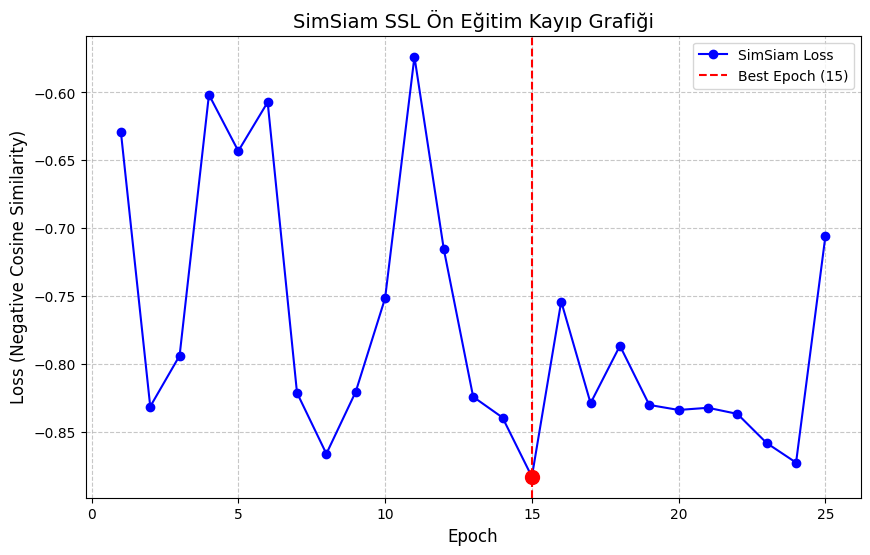

In [7]:
import matplotlib.pyplot as plt


ssl_losses = [
    -0.6085, -0.8179, -0.8110, -0.7263, -0.6637, 
    -0.7682, -0.8593, -0.8262, -0.7248, -0.5836, 
    -0.7107, -0.5527, -0.7885, -0.8837, -0.8192, 
    -0.7726, -0.8045, -0.7959, -0.7923, -0.8640, 
    -0.8276, -0.7512, -0.8159, -0.7129
]

epochs = range(1, len(losses) + 1)
best_epoch = losses.index(min(losses)) + 1
best_loss = min(losses)

plt.figure(figsize=(10, 6))
plt.plot(epochs, losses, marker='o', linestyle='-', color='b', label='SimSiam Loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.scatter(best_epoch, best_loss, color='red', s=100, zorder=5) # En iyi noktayı işaretle

plt.title('SimSiam SSL Ön Eğitim Kayıp Grafiği', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Negative Cosine Similarity)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Sunum için arka planı beyaz yapalım
plt.gca().set_facecolor('white')
plt.show() 

In [8]:
# ============================================================
# 5. CLASSIFIER MODEL VE EĞİTİM
# ============================================================
class Classifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.fc = nn.Linear(512, 2)
    
    def forward(self, x):
        features = self.encoder(x).squeeze()
        return self.fc(features)

# En iyi modeli hazırla
final_model = Classifier(deepcopy(ssl_model.encoder)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-4, weight_decay=1e-4)

# Eğitim metrikleri
train_losses = []
train_accs = []
val_accs = []

print("\n🎯 Sınıflandırma Modeli Eğitimi Başlıyor...")
EPOCHS = 30
best_val_acc = 0.0

for epoch in range(EPOCHS):
    # Training
    final_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for x, y in cls_train_loader:
        x, y = x.to(device), y.to(device)
        outputs = final_model(x)
        loss = criterion(outputs, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    epoch_loss = running_loss / len(cls_train_loader)
    train_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(train_acc)
    
    # Validation
    final_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in cls_test_loader:
            x, y = x.to(device), y.to(device)
            outputs = final_model(x)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
    
    val_acc = 100. * correct / total
    val_accs.append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = deepcopy(final_model.state_dict())
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

# En iyi modeli yükle
final_model.load_state_dict(best_model_weights)
print(f"\n✅ En İyi Validasyon Doğruluğu: {best_val_acc:.2f}%")
 


🎯 Sınıflandırma Modeli Eğitimi Başlıyor...
Epoch [1/30] Loss: 0.4728 | Train Acc: 77.13% | Val Acc: 80.95%
Epoch [2/30] Loss: 0.3026 | Train Acc: 89.46% | Val Acc: 85.03%
Epoch [3/30] Loss: 0.2402 | Train Acc: 91.16% | Val Acc: 89.12%
Epoch [4/30] Loss: 0.2547 | Train Acc: 90.82% | Val Acc: 86.39%
Epoch [5/30] Loss: 0.1734 | Train Acc: 94.47% | Val Acc: 79.93%
Epoch [6/30] Loss: 0.1630 | Train Acc: 94.81% | Val Acc: 92.86%
Epoch [7/30] Loss: 0.1296 | Train Acc: 95.75% | Val Acc: 95.24%
Epoch [8/30] Loss: 0.1153 | Train Acc: 96.60% | Val Acc: 95.24%
Epoch [9/30] Loss: 0.1080 | Train Acc: 95.83% | Val Acc: 95.24%
Epoch [10/30] Loss: 0.0851 | Train Acc: 97.36% | Val Acc: 94.56%
Epoch [11/30] Loss: 0.1231 | Train Acc: 95.24% | Val Acc: 87.76%
Epoch [12/30] Loss: 0.0805 | Train Acc: 97.28% | Val Acc: 95.58%
Epoch [13/30] Loss: 0.0745 | Train Acc: 97.62% | Val Acc: 94.56%
Epoch [14/30] Loss: 0.0608 | Train Acc: 98.30% | Val Acc: 96.26%
Epoch [15/30] Loss: 0.0437 | Train Acc: 98.72% | Val Ac

In [9]:
# ============================================================
# 5. CLASSIFIER MODEL
# ============================================================
class Classifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.fc = nn.Linear(512, 2)
    
    def forward(self, x):
        features = self.encoder(x).squeeze()
        return self.fc(features)

In [11]:


# ============================================================
# 6. HİPERPARAMETRE OPTİMİZASYONU (Grid Search)
# ============================================================
import itertools
from copy import deepcopy

# Denenecek hiperparametre havuzu
lrs = [1e-3, 1e-4, 1e-5]
wds = [1e-3, 1e-4, 1e-5]
batch_sizes = [32]  # İsterseniz [16, 32, 64] gibi genişletebilirsiniz

HYPERPARAM_EPOCHS = 20  # Her kombinasyon için epoch sayısı
best_val_acc = 0.0
best_config = {}
all_results = []

criterion = nn.CrossEntropyLoss()

print("\n" + "="*70)
print("🚀 HİPERPARAMETRE OPTİMİZASYONU BAŞLIYOR (Grid Search)")
print("="*70)
print(f"Toplam Kombinasyon: {len(lrs) * len(wds) * len(batch_sizes)}")
print(f"Her Kombinasyon için Epoch: {HYPERPARAM_EPOCHS}")
print("="*70 + "\n")

# Tüm kombinasyonları dene
for combo_idx, (lr, wd, bs) in enumerate(itertools.product(lrs, wds, batch_sizes), 1):
    print(f"\n{'='*70}")
    print(f"[{combo_idx}/{len(lrs)*len(wds)*len(batch_sizes)}] Deneniyor: LR={lr}, WD={wd}, Batch Size={bs}")
    print(f"{'='*70}")
    
    # DataLoader'ı batch size'a göre yeniden oluştur
    if bs != 32:
        temp_train_loader = DataLoader(
            ClsDataset(cls_train_imgs, cls_train_lbls, cls_transform), 
            batch_size=bs, shuffle=True
        )
        temp_test_loader = DataLoader(
            ClsDataset(cls_test_imgs, cls_test_lbls, cls_transform), 
            batch_size=bs
        )
    else:
        temp_train_loader = cls_train_loader
        temp_test_loader = cls_test_loader
    
    # Her seferinde SSL'den gelen temiz encoder ile başla
    temp_model = Classifier(deepcopy(ssl_model.encoder)).to(device)
    optimizer = torch.optim.Adam(temp_model.parameters(), lr=lr, weight_decay=wd)
    
    # Bu kombinasyon için eğitim metrikleri
    combo_train_accs = []
    combo_val_accs = []
    combo_train_losses = []
    
    for epoch in range(HYPERPARAM_EPOCHS):
        # Training
        temp_model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for x, y in temp_train_loader:
            x, y = x.to(device), y.to(device)
            outputs = temp_model(x)
            loss = criterion(outputs, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
        
        epoch_loss = running_loss / len(temp_train_loader)
        train_acc = 100. * correct / total
        combo_train_losses.append(epoch_loss)
        combo_train_accs.append(train_acc)
        
        # Validation
        temp_model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in temp_test_loader:
                x, y = x.to(device), y.to(device)
                outputs = temp_model(x)
                _, predicted = outputs.max(1)
                total += y.size(0)
                correct += predicted.eq(y).sum().item()
        
        val_acc = 100. * correct / total
        combo_val_accs.append(val_acc)
        
        # Her 5 epoch'ta bir progress göster
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch [{epoch+1}/{HYPERPARAM_EPOCHS}] "
                  f"Loss: {epoch_loss:.4f} | "
                  f"Train Acc: {train_acc:.2f}% | "
                  f"Val Acc: {val_acc:.2f}%")
    
    # Bu kombinasyonun final val accuracy'si
    final_val_acc = combo_val_accs[-1]
    
    # Sonuçları kaydet
    result = {
        'lr': lr,
        'wd': wd,
        'batch_size': bs,
        'final_val_acc': final_val_acc,
        'best_val_acc': max(combo_val_accs),
        'train_accs': combo_train_accs,
        'val_accs': combo_val_accs,
        'train_losses': combo_train_losses
    }
    all_results.append(result)
    
    print(f"\n  📊 Sonuç: Final Val Acc = {final_val_acc:.2f}% | "
          f"Best Val Acc = {max(combo_val_accs):.2f}%")
    
    # En iyi modeli kaydet
    if max(combo_val_accs) > best_val_acc:
        best_val_acc = max(combo_val_accs)
        best_config = {'lr': lr, 'wd': wd, 'batch_size': bs}
        best_model_weights = deepcopy(temp_model.state_dict())
        print(f"  ✨ Yeni En İyi Model! (Val Acc: {best_val_acc:.2f}%)")

print("\n" + "="*70)
print("✅ HİPERPARAMETRE OPTİMİZASYONU TAMAMLANDI!")
print("="*70)
print(f"\n🏆 EN İYİ SONUÇLAR:")
print(f"  • Learning Rate:    {best_config['lr']}")
print(f"  • Weight Decay:     {best_config['wd']}")
print(f"  • Batch Size:       {best_config['batch_size']}")
print(f"  • Best Val Acc:     {best_val_acc:.2f}%")
print("="*70)





🚀 HİPERPARAMETRE OPTİMİZASYONU BAŞLIYOR (Grid Search)
Toplam Kombinasyon: 9
Her Kombinasyon için Epoch: 20


[1/9] Deneniyor: LR=0.001, WD=0.001, Batch Size=32
  Epoch [5/20] Loss: 0.1579 | Train Acc: 94.47% | Val Acc: 64.97%
  Epoch [10/20] Loss: 0.1715 | Train Acc: 93.20% | Val Acc: 57.14%
  Epoch [15/20] Loss: 0.0969 | Train Acc: 96.94% | Val Acc: 98.98%
  Epoch [20/20] Loss: 0.0721 | Train Acc: 97.36% | Val Acc: 60.54%

  📊 Sonuç: Final Val Acc = 60.54% | Best Val Acc = 98.98%
  ✨ Yeni En İyi Model! (Val Acc: 98.98%)

[2/9] Deneniyor: LR=0.001, WD=0.0001, Batch Size=32
  Epoch [5/20] Loss: 0.1176 | Train Acc: 94.73% | Val Acc: 94.90%
  Epoch [10/20] Loss: 0.0904 | Train Acc: 96.34% | Val Acc: 93.54%
  Epoch [15/20] Loss: 0.0657 | Train Acc: 96.85% | Val Acc: 75.85%
  Epoch [20/20] Loss: 0.0589 | Train Acc: 98.30% | Val Acc: 85.71%

  📊 Sonuç: Final Val Acc = 85.71% | Best Val Acc = 96.94%

[3/9] Deneniyor: LR=0.001, WD=1e-05, Batch Size=32
  Epoch [5/20] Loss: 0.1574 | Train Acc: 

In [12]:
# ============================================================
# 7. EN İYİ MODELİ YÜKLE VE DETAYLI EĞİT--eski
# ============================================================
print("\n" + "="*70)
print("🎯 EN İYİ HİPERPARAMETRELERLE DETAYLI EĞİTİM BAŞLIYOR")
print("="*70)

# En iyi konfigürasyonla model oluştur
final_model = Classifier(deepcopy(ssl_model.encoder)).to(device)
final_model.load_state_dict(best_model_weights)

# En iyi batch size ile DataLoader oluştur
if best_config['batch_size'] != 32:
    final_train_loader = DataLoader(
        ClsDataset(cls_train_imgs, cls_train_lbls, cls_transform), 
        batch_size=best_config['batch_size'], shuffle=True
    )
    final_test_loader = DataLoader(
        ClsDataset(cls_test_imgs, cls_test_lbls, cls_transform), 
        batch_size=best_config['batch_size']
    )
else:
    final_train_loader = cls_train_loader
    final_test_loader = cls_test_loader

optimizer = torch.optim.Adam(
    final_model.parameters(), 
    lr=best_config['lr'], 
    weight_decay=best_config['wd']
)

# Final eğitim metrikleri
train_losses = []
train_accs = []
val_accs = []

FINAL_EPOCHS = 50
best_final_val_acc = 0.0
patience = 10
counter = 0

for epoch in range(FINAL_EPOCHS):
    # Training
    final_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for x, y in final_train_loader:
        x, y = x.to(device), y.to(device)
        outputs = final_model(x)
        loss = criterion(outputs, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    epoch_loss = running_loss / len(final_train_loader)
    train_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(train_acc)
    
    # Validation
    final_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in final_test_loader:
            x, y = x.to(device), y.to(device)
            outputs = final_model(x)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
    
    val_acc = 100. * correct / total
    val_accs.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{FINAL_EPOCHS}] "
          f"Loss: {epoch_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Val Acc: {val_acc:.2f}%")
    
    # En iyi modeli kaydet
    if val_acc > best_final_val_acc:
        best_final_val_acc = val_acc
        best_final_weights = deepcopy(final_model.state_dict())
        counter = 0
        print(f"  ✨ Yeni En İyi! Val Acc: {val_acc:.2f}%")
    else:
        counter += 1
        if counter >= patience:
            print(f"\n⏸ Early Stopping: {patience} epoch boyunca iyileşme olmadı.")
            break

# En iyi modeli yükle
final_model.load_state_dict(best_final_weights)

print("\n" + "="*70)
print("✅ EĞİTİM TAMAMLANDI!")
print("="*70)
print(f"  • En İyi Validasyon Doğruluğu: {best_final_val_acc:.2f}%")
print(f"  • Toplam Epoch: {len(train_losses)}")
print("="*70) 


🎯 EN İYİ HİPERPARAMETRELERLE DETAYLI EĞİTİM BAŞLIYOR
Epoch [1/50] Loss: 0.0387 | Train Acc: 98.55% | Val Acc: 99.66%
  ✨ Yeni En İyi! Val Acc: 99.66%
Epoch [2/50] Loss: 0.0292 | Train Acc: 98.98% | Val Acc: 98.64%
Epoch [3/50] Loss: 0.0556 | Train Acc: 98.04% | Val Acc: 99.32%
Epoch [4/50] Loss: 0.0397 | Train Acc: 98.81% | Val Acc: 98.98%
Epoch [5/50] Loss: 0.0212 | Train Acc: 99.49% | Val Acc: 93.54%
Epoch [6/50] Loss: 0.0305 | Train Acc: 98.98% | Val Acc: 96.94%
Epoch [7/50] Loss: 0.0139 | Train Acc: 99.57% | Val Acc: 99.32%
Epoch [8/50] Loss: 0.0179 | Train Acc: 99.40% | Val Acc: 99.32%
Epoch [9/50] Loss: 0.0194 | Train Acc: 99.23% | Val Acc: 98.64%
Epoch [10/50] Loss: 0.0127 | Train Acc: 99.66% | Val Acc: 98.98%
Epoch [11/50] Loss: 0.0433 | Train Acc: 98.72% | Val Acc: 98.30%

⏸ Early Stopping: 10 epoch boyunca iyileşme olmadı.

✅ EĞİTİM TAMAMLANDI!
  • En İyi Validasyon Doğruluğu: 99.66%
  • Toplam Epoch: 11



📈 Eğitim Grafikleri Oluşturuluyor...


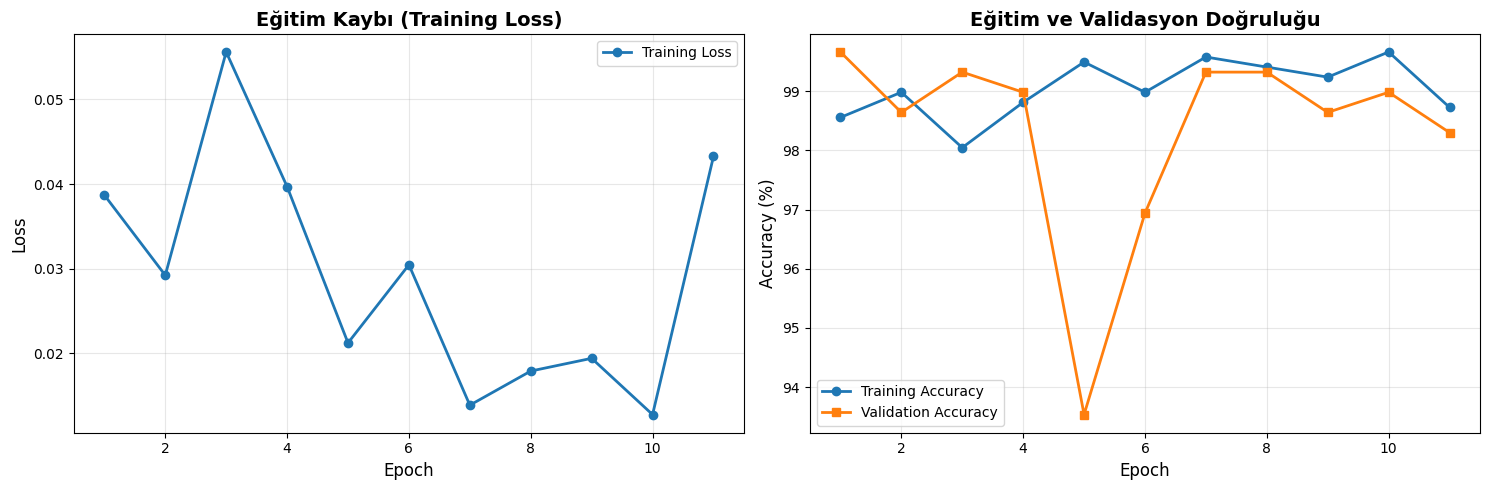

In [13]:
# ============================================================
# 8. EĞİTİM GRAFİKLERİ
# ============================================================
print("\n📈 Eğitim Grafikleri Oluşturuluyor...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss grafiği
axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Training Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Eğitim Kaybı (Training Loss)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy grafiği
axes[1].plot(range(1, len(train_accs) + 1), train_accs, marker='o', label='Training Accuracy', linewidth=2)
axes[1].plot(range(1, len(val_accs) + 1), val_accs, marker='s', label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Eğitim ve Validasyon Doğruluğu', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🎨 t-SNE ile Feature Space Görselleştiriliyor...


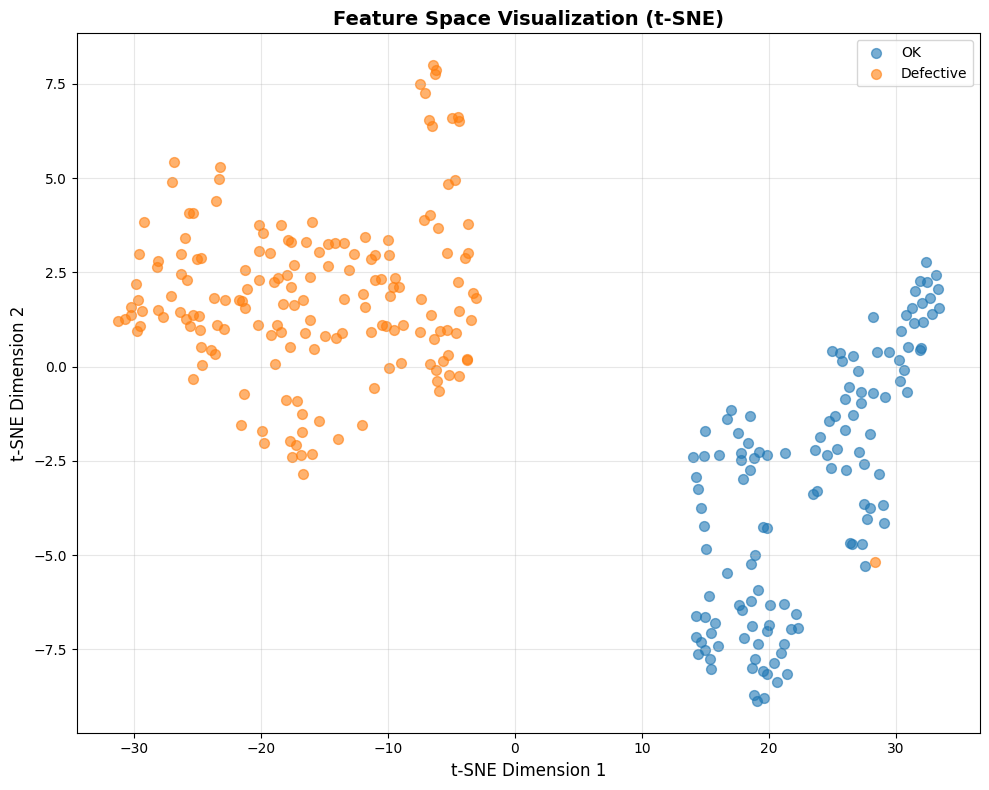

In [15]:
# ============================================================
# 12. t-SNE GÖRSELLEŞTİRME (Feature Space)
# ============================================================
print("\n🎨 t-SNE ile Feature Space Görselleştiriliyor...")

def extract_features(model, loader, device):
    model.eval()
    features = []
    labels = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            feat = model.encoder(x).squeeze().cpu().numpy()
            features.append(feat)
            labels.extend(y.numpy())
    
    return np.vstack(features), np.array(labels)

test_features, test_labels = extract_features(final_model, cls_test_loader, device)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(test_features)

fig, ax = plt.subplots(figsize=(10, 8))
for class_idx, class_name in enumerate(['OK', 'Defective']):
    mask = test_labels == class_idx
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1], 
               label=class_name, alpha=0.6, s=50)

ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.set_title('Feature Space Visualization (t-SNE)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



print("="*60)


📊 Hiperparametre Optimizasyon Sonuçları Görselleştiriliyor...

📋 Tüm Kombinasyonların Sonuçları (En İyiden En Kötüye):
     LR      WD  Batch Size  Best Val Acc               Config
0.00010 0.00010          32     99.659864 LR=0.0001, WD=0.0001
0.00010 0.00001          32     99.319728  LR=0.0001, WD=1e-05
0.00100 0.00100          32     98.979592   LR=0.001, WD=0.001
0.00001 0.00100          32     98.979592   LR=1e-05, WD=0.001
0.00010 0.00100          32     97.619048  LR=0.0001, WD=0.001
0.00100 0.00001          32     97.278912   LR=0.001, WD=1e-05
0.00100 0.00010          32     96.938776  LR=0.001, WD=0.0001
0.00001 0.00010          32     96.598639  LR=1e-05, WD=0.0001
0.00001 0.00001          32     96.598639   LR=1e-05, WD=1e-05


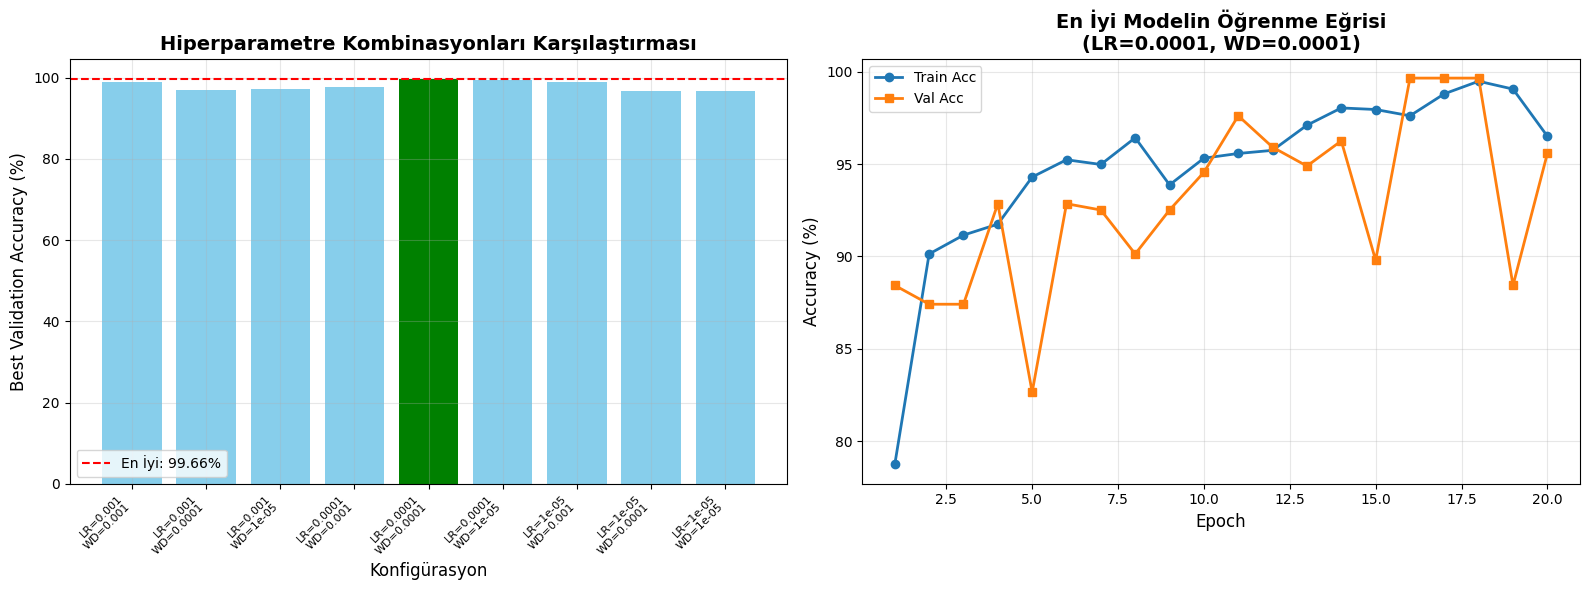


✅ Hiperparametre optimizasyonu ve görselleştirme tamamlandı!


In [16]:
# ============================================================
# 8. HİPERPARAMETRE SONUÇLARINI GÖRSELLEŞTİR
# ============================================================
print("\n📊 Hiperparametre Optimizasyon Sonuçları Görselleştiriliyor...")

# Sonuçları DataFrame'e çevir (görselleştirme için)
import pandas as pd

results_df = pd.DataFrame([
    {
        'LR': r['lr'],
        'WD': r['wd'],
        'Batch Size': r['batch_size'],
        'Best Val Acc': r['best_val_acc'],
        'Config': f"LR={r['lr']}, WD={r['wd']}"
    }
    for r in all_results
])

# Sıralama
results_df = results_df.sort_values('Best Val Acc', ascending=False)

print("\n📋 Tüm Kombinasyonların Sonuçları (En İyiden En Kötüye):")
print(results_df.to_string(index=False))

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar plot - Tüm kombinasyonlar
configs = [f"LR={r['lr']}\nWD={r['wd']}" for r in all_results]
accs = [r['best_val_acc'] for r in all_results]
colors = ['green' if acc == max(accs) else 'skyblue' for acc in accs]

axes[0].bar(range(len(configs)), accs, color=colors)
axes[0].set_xlabel('Konfigürasyon', fontsize=12)
axes[0].set_ylabel('Best Validation Accuracy (%)', fontsize=12)
axes[0].set_title('Hiperparametre Kombinasyonları Karşılaştırması', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(configs)))
axes[0].set_xticklabels(configs, rotation=45, ha='right', fontsize=8)
axes[0].axhline(y=best_val_acc, color='red', linestyle='--', label=f'En İyi: {best_val_acc:.2f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Learning curve - En iyi model
best_result = max(all_results, key=lambda x: x['best_val_acc'])
epochs_range = range(1, len(best_result['val_accs']) + 1)

axes[1].plot(epochs_range, best_result['train_accs'], marker='o', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, best_result['val_accs'], marker='s', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title(f'En İyi Modelin Öğrenme Eğrisi\n(LR={best_config["lr"]}, WD={best_config["wd"]})', 
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Hiperparametre optimizasyonu ve görselleştirme tamamlandı!")

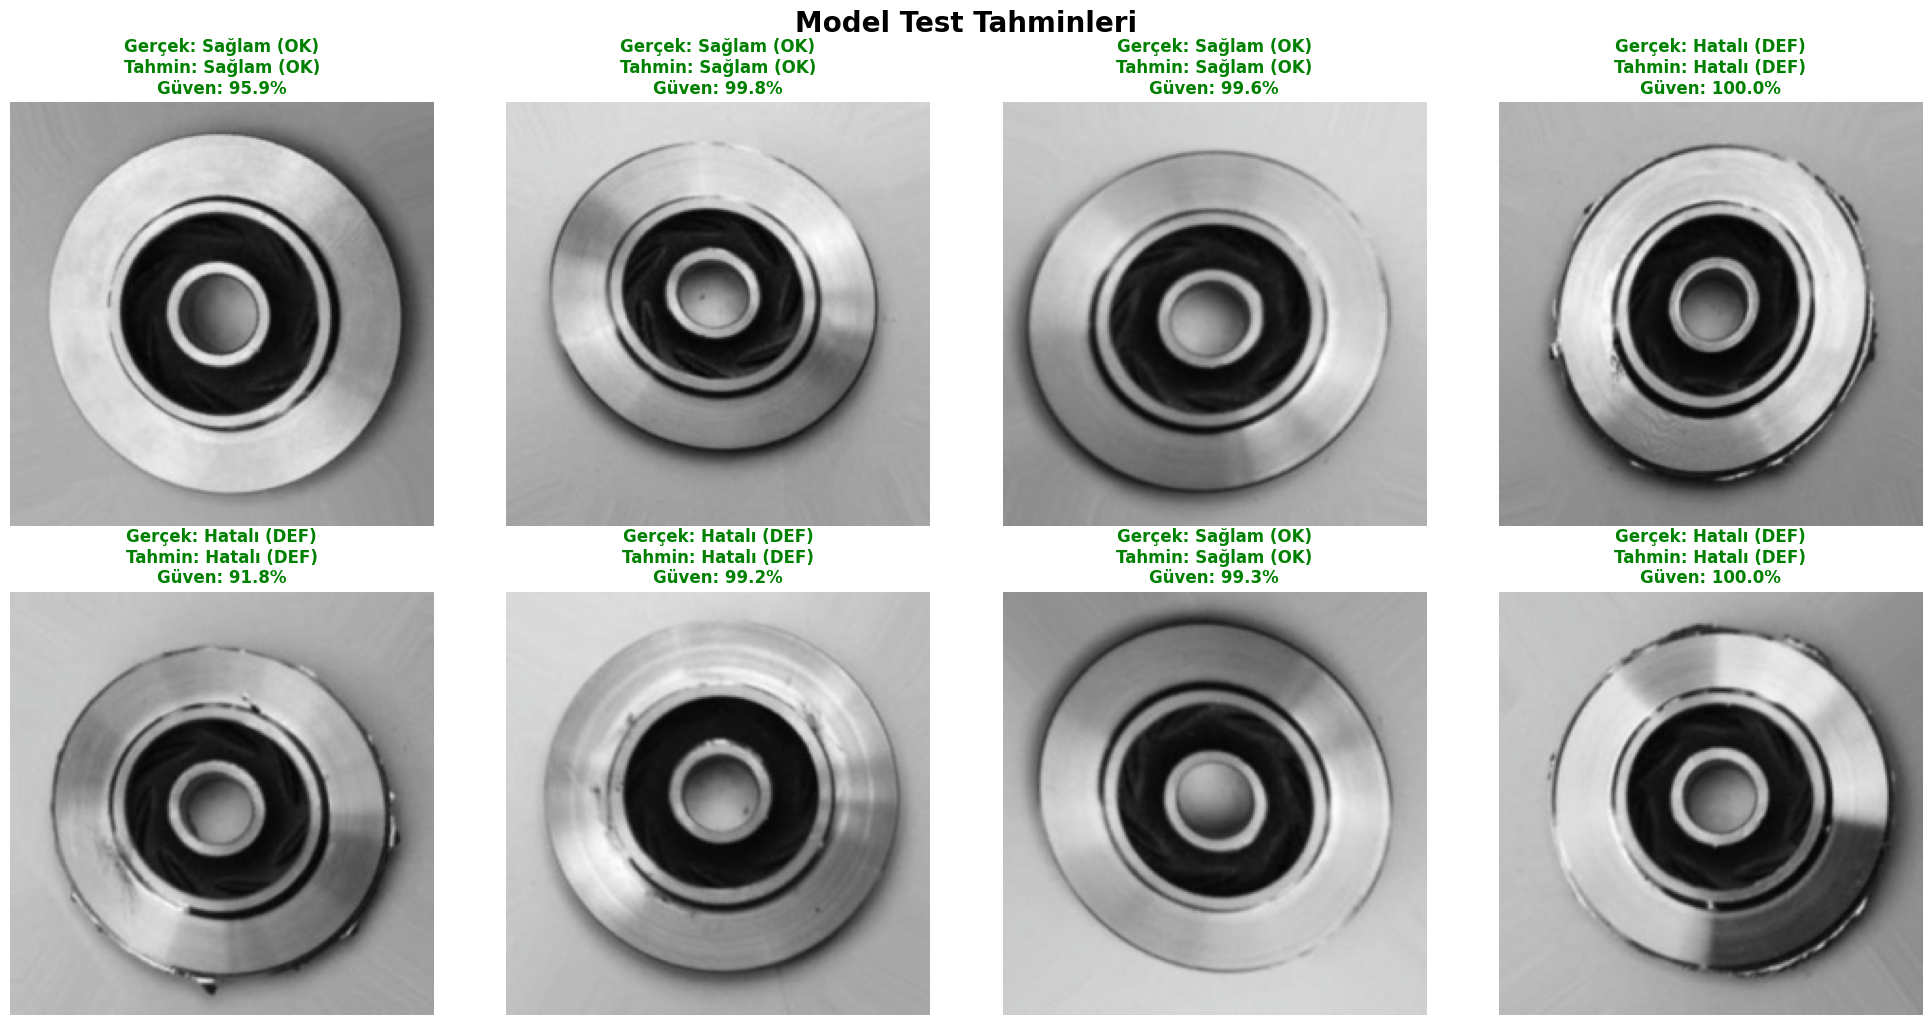

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

def visualize_pytorch_predictions(model, loader, classes, num_images=8):
    # 1. Modeli değerlendirme moduna al ve verileri çek
    model.eval()
    images, labels = next(iter(loader)) # PyTorch DataLoader'dan bir batch al
    
    # Verileri mevcut cihaza (cuda/cpu) gönder
    images_gpu = images.to(device)
    
    # 2. Tahminleri üret
    with torch.no_grad():
        outputs = model(images_gpu)
        probs = torch.softmax(outputs, dim=1) # Olasılıkları hesapla
        preds = torch.argmax(outputs, dim=1)  # En yüksek olasılıklı sınıfı seç
    
    # 3. Görselleştirme
    plt.figure(figsize=(20, 10))
    
    for i in range(min(num_images, len(images))):
        plt.subplot(2, 4, i + 1)
        
        # Resmi görselleştirme için hazırla (Normalize işlemini geri alarak)
        img = images[i].cpu().numpy().transpose((1, 2, 0)) # (C,H,W) -> (H,W,C)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean # Normalizasyonu tersine çevir
        img = np.clip(img, 0, 1)
        
        plt.imshow(img)
        
        true_idx = labels[i].item()
        pred_idx = preds[i].item()
        confidence = probs[i][pred_idx].item() * 100
        
        # Renk kuralı: Doğruysa yeşil, yanlışsa kırmızı
        color = 'green' if true_idx == pred_idx else 'red'
        
        plt.title(f"Gerçek: {classes[true_idx]}\nTahmin: {classes[pred_idx]}\nGüven: {confidence:.1f}%", 
                  color=color, fontsize=12, fontweight='bold')
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle("Model Test Tahminleri", fontsize=20, y=1.02, fontweight='bold')
    plt.show()

# 4. KODU ÇALIŞTIR
# Sınıf isimlerini senin projendeki sırayla veriyoruz
CLASSES = ['Sağlam (OK)', 'Hatalı (DEF)'] 
visualize_pytorch_predictions(final_model, cls_test_loader, CLASSES)

🔢 Test verileri üzerinden tahminler toplanıyor...


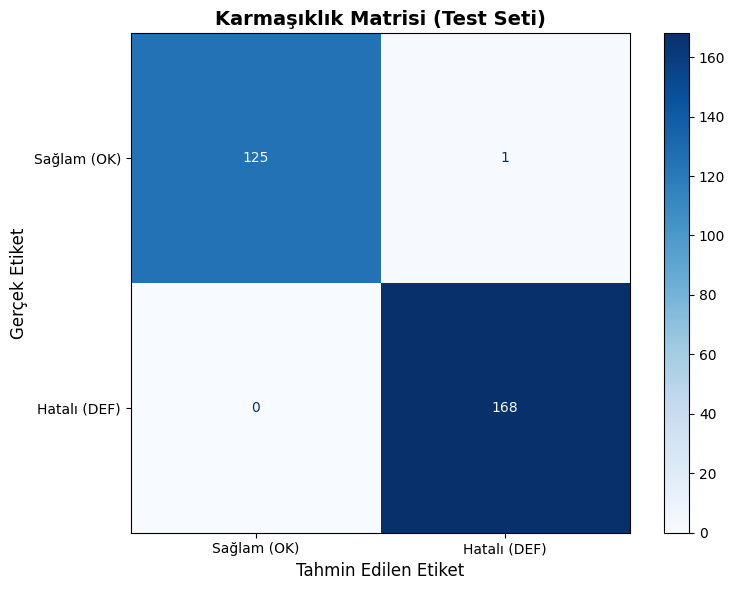

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import matplotlib.pyplot as plt

# 1. LİSTELERİ SIFIRDAN DOLDUR (Hata Almamak İçin)
final_model.eval()
all_preds = []
all_labels = []

print("🔢 Test verileri üzerinden tahminler toplanıyor...")
with torch.no_grad():
    for images, labels in final_test_loader: # Kendi loader ismini kontrol et (cls_test_loader da olabilir)
        images = images.to(device)
        outputs = final_model(images)
        preds = torch.argmax(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. CONFUSION MATRIX HESAPLA
cm = confusion_matrix(all_labels, all_preds)

# 3. GÖRSELLEŞTİRME
fig, ax = plt.subplots(figsize=(8, 6))

# Sınıf isimlerini senin veri setine göre ayarladık
# Genellikle 0: Sağlam (OK), 1: Hatalı (DEF) şeklindedir
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Sağlam (OK)', 'Hatalı (DEF)'])

disp.plot(ax=ax, cmap='Blues', values_format='d')

ax.set_title('Karmaşıklık Matrisi (Test Seti)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin Edilen Etiket', fontsize=12)
ax.set_ylabel('Gerçek Etiket', fontsize=12)

plt.tight_layout()
plt.show()

In [38]:

class_names = ['Hatalı (Defective)', 'Sağlam (OK)']

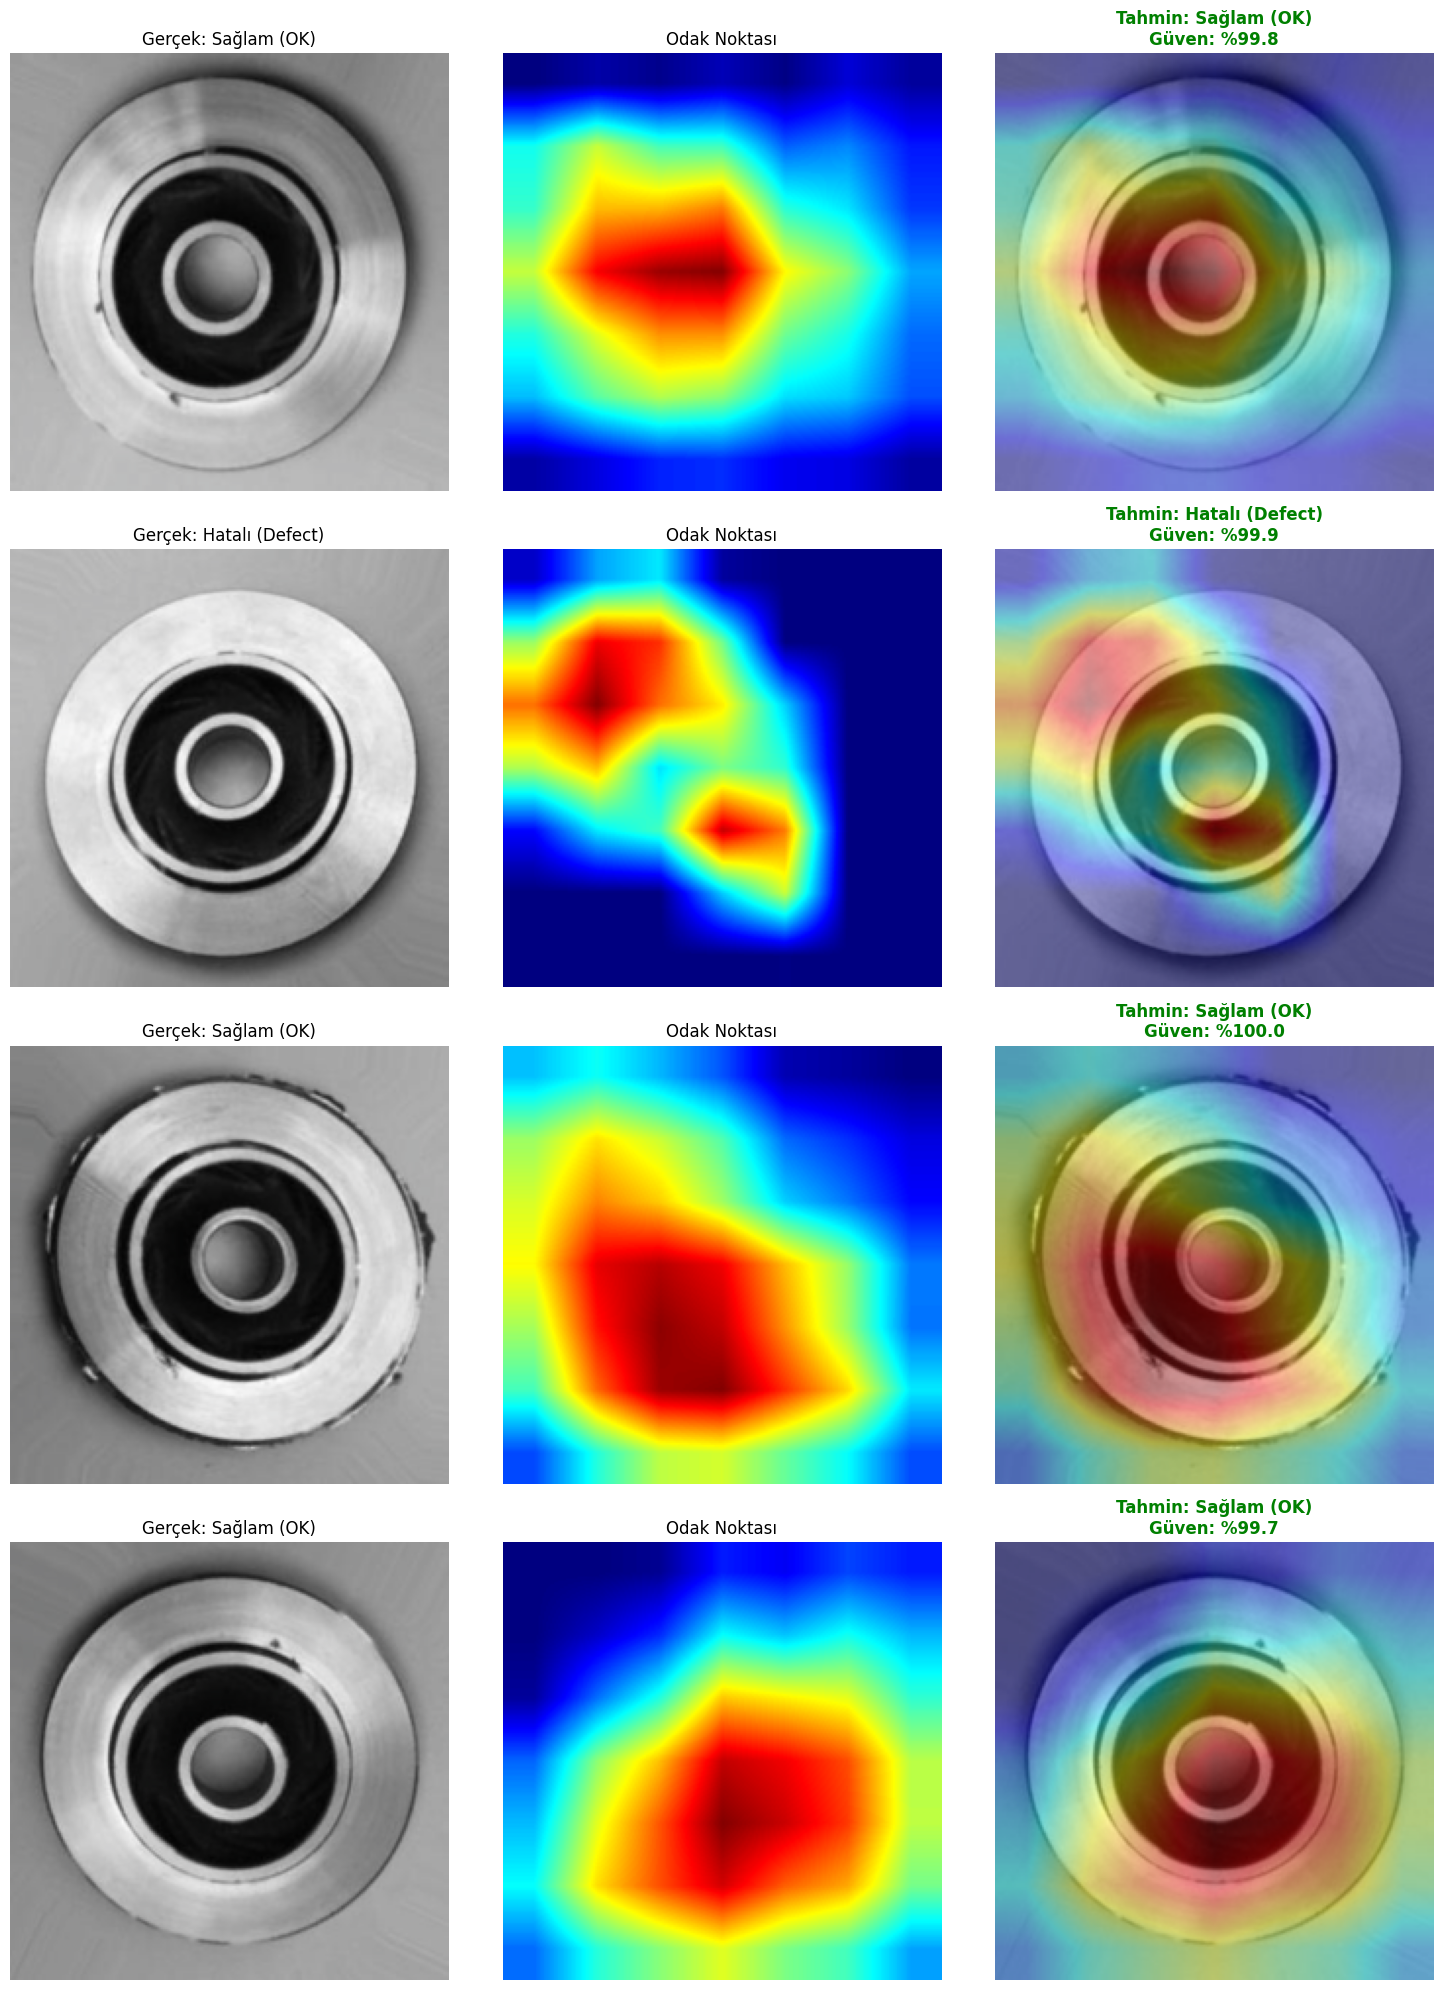

In [39]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook'lar
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, target_class):
        self.model.eval()
        # Gradyan takibini açıyoruz çünkü Grad-CAM buna ihtiyaç duyar
        with torch.set_grad_enabled(True):
            x.requires_grad = True
            output = self.model(x)
            
            # Boyut düzeltme: Eğer [batch] ise [1, batch] yapıyoruz
            if output.dim() == 1:
                output = output.unsqueeze(0)
            
            self.model.zero_grad()
            loss = output[0, target_class]
            loss.backward()

            weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
            cam = torch.sum(weights * self.activations, dim=1).squeeze()
            
            cam = F.relu(cam)
            cam -= cam.min()
            cam /= (cam.max() + 1e-10)
            return cam.cpu().numpy()

def visualize_final_gradcam(model, dataset, num_samples=4):
    # Son Conv katmanını bul
    target_layer = None
    for module in reversed(list(model.encoder.modules())):
        if isinstance(module, torch.nn.Conv2d):
            target_layer = module
            break
            
    grad_cam = GradCAM(model, target_layer)
    
    # Etiketler: 0 -> Defective (Hatalı), 1 -> OK (Sağlam)
    class_names = ['Hatalı (Defect)', 'Sağlam (OK)']
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    for idx, s_idx in enumerate(indices):
        img_tensor, true_label = dataset[s_idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            output = model(input_tensor)
            
            # BOYUT HATASI ÇÖZÜMÜ: Çıktıyı 2 boyutlu hale getiriyoruz
            if output.dim() == 1:
                output = output.unsqueeze(0)
                
            probs = torch.softmax(output, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()
            conf = probs[0, pred_class].item()

        # Isı haritası
        heatmap_raw = grad_cam(input_tensor, pred_class)
        
        # Denormalizasyon
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(np.array([0.229, 0.224, 0.225]) * img_np + np.array([0.485, 0.456, 0.406]), 0, 1)
        img_uint8 = np.uint8(255 * img_np)
        
        heatmap_resized = cv2.resize(heatmap_raw, (224, 224))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        superimposed = cv2.addWeighted(img_uint8, 0.6, heatmap_color, 0.4, 0)
        
        axes[idx, 0].imshow(img_np)
        axes[idx, 0].set_title(f"Gerçek: {class_names[true_label]}")
        axes[idx, 1].imshow(heatmap_color)
        axes[idx, 1].set_title("Odak Noktası")
        
        color = 'green' if pred_class == true_label else 'red'
        axes[idx, 2].imshow(superimposed)
        axes[idx, 2].set_title(f"Tahmin: {class_names[pred_class]}\nGüven: %{conf*100:.1f}", color=color, fontweight='bold')
        
        for ax in axes[idx]: ax.axis('off')

    plt.tight_layout()
    plt.show()

# ÇALIŞTIR
visualize_final_gradcam(final_model, test_dataset_obj)